# Taller 2: Regresión

In [1]:

import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/training_pruebas.csv', header=0)
dfTest = pd.read_csv('data/test_pruebas.csv', header=0)

C:\Users\Migue\AppData\Local\Temp\ipykernel_17736\874024968.py:1: DtypeWarning: Columns (49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/training_pruebas.csv', header=0)
C:\Users\Migue\AppData\Local\Temp\ipykernel_17736\874024968.py:2: DtypeWarning: Columns (49) have mixed types. Specify dtype option on import or set low_memory=False.
  dfTest = pd.read_csv('data/test_pruebas.csv', header=0)


# Seleccionar variables

- ESTU_FECHANACIMIENTO 
- ESTU_DEPTO_RESIDE 
- ESTU_AREARESIDE 
- ESTU_TITULOOBTENIDOBACHILLER 
- ESTU_GENERO
- ESTU_COMOCAPACITOEXAMENSB11 
- ESTU_TIPODOCUMENTOSB11 
- FAMI_EDUCACIONPADRE 
- FAMI_EDUCACIONMADRE
- FAMI_OCUPACIONPADRE 
- FAMI_OCUPACIONMADRE 
- FAMI_TIENEINTERNET
- ESTU_HORASSEMANATRABAJA 
- ESTU_VLRULTIMOSEMESCURSADO
- ESTU_PRGM_ACADEMICO

In [12]:
def generarGraficoDummies(dummies, columna):
    frecuencias_dummies = dummies.sum()
    plt.figure(figsize=(10,6))

    frecuencias_dummies.plot(kind='bar')

    # Añadir títulos y etiquetas
    plt.title(f'Distribución de las variables dummy de {columna}', fontsize=16)
    plt.xlabel(columna, fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.xticks(rotation=90)  # Rotar las etiquetas en el eje X si son largas
    plt.tight_layout()  # Ajustar los márgenes del gráfico
    plt.show()

ESTU_FECHANACIMIENTO

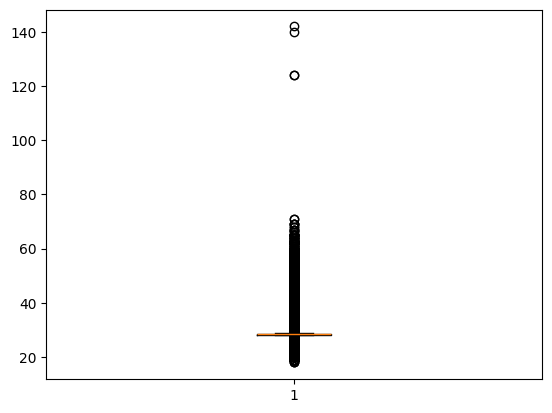

In [6]:
def edad(df, fecha):
    df[fecha] = pd.to_datetime(df[fecha], errors='coerce')
    fecha_actual = datetime.now()
    df['EDAD'] = df[fecha].apply(lambda fecha: fecha_actual.year - fecha.year - ((fecha_actual.month, fecha_actual.day) < (fecha.month, fecha.day)))
    return df

df = edad(df, 'ESTU_FECHANACIMIENTO')
MEAN = df['EDAD'].mean()
df['EDAD'] = df['EDAD'].fillna(MEAN)
dfTrain = df['EDAD']

plt.boxplot(df['EDAD'])

dfTest = edad(dfTest, 'ESTU_FECHANACIMIENTO')
MEAN = dfTest['EDAD'].mean()
dfTest['EDAD'] = dfTest['EDAD'].fillna(MEAN)

ESTU_DEPTO_RESIDE

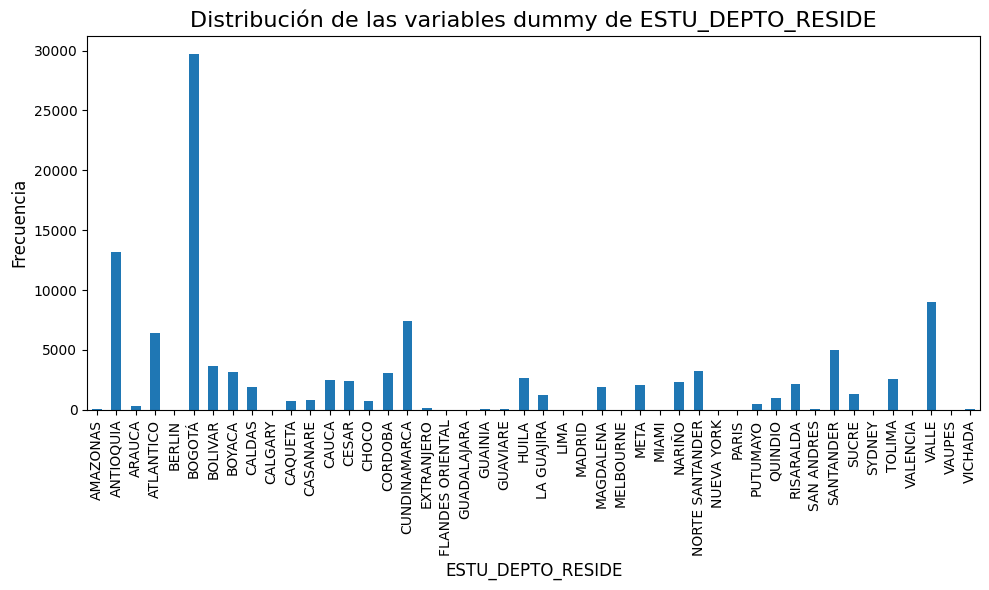

In [19]:
dummies = pd.get_dummies(df['ESTU_DEPTO_RESIDE'], prefix='ESTU_DEPTO_RESIDE', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['ESTU_DEPTO_RESIDE']), 'ESTU_DEPTO_RESIDE')

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['ESTU_DEPTO_RESIDE'], prefix='ESTU_DEPTO_RESIDE', drop_first=True)], axis=1)

ESTU_AREARESIDE

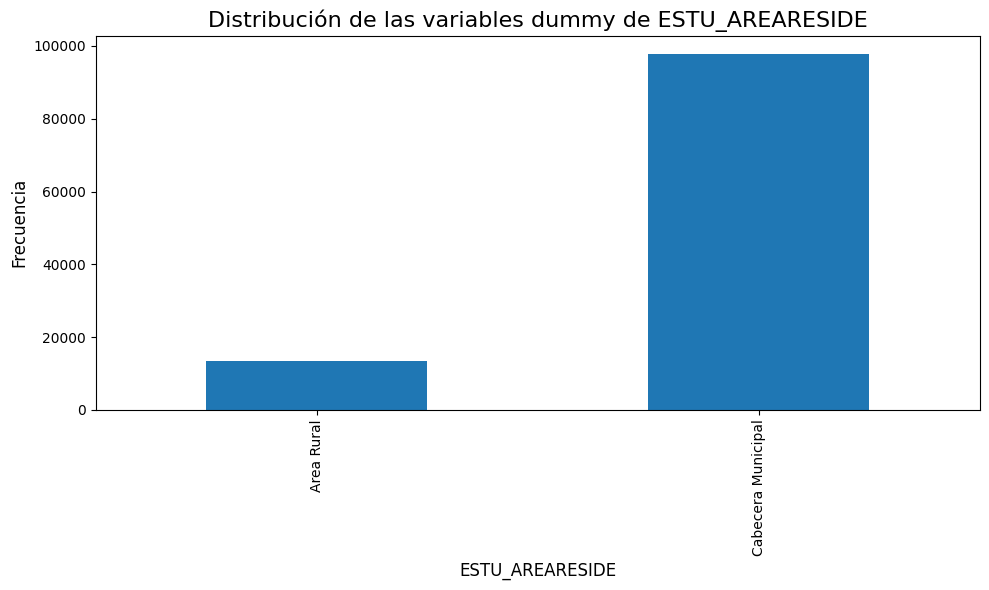

In [20]:
MODAL = df['ESTU_AREARESIDE'].value_counts().idxmax()
df['ESTU_AREARESIDE'] = df['ESTU_AREARESIDE'].fillna(MODAL)

dummies = pd.get_dummies(df['ESTU_AREARESIDE'], prefix='ESTU_AREARESIDE', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['ESTU_AREARESIDE']), 'ESTU_AREARESIDE')

MODAL = dfTest['ESTU_AREARESIDE'].value_counts().idxmax()
dfTest['ESTU_AREARESIDE'] = dfTest['ESTU_AREARESIDE'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['ESTU_AREARESIDE'], prefix='ESTU_AREARESIDE', drop_first=True)], axis=1)

ESTU_TITULOOBTENIDOBACHILLER

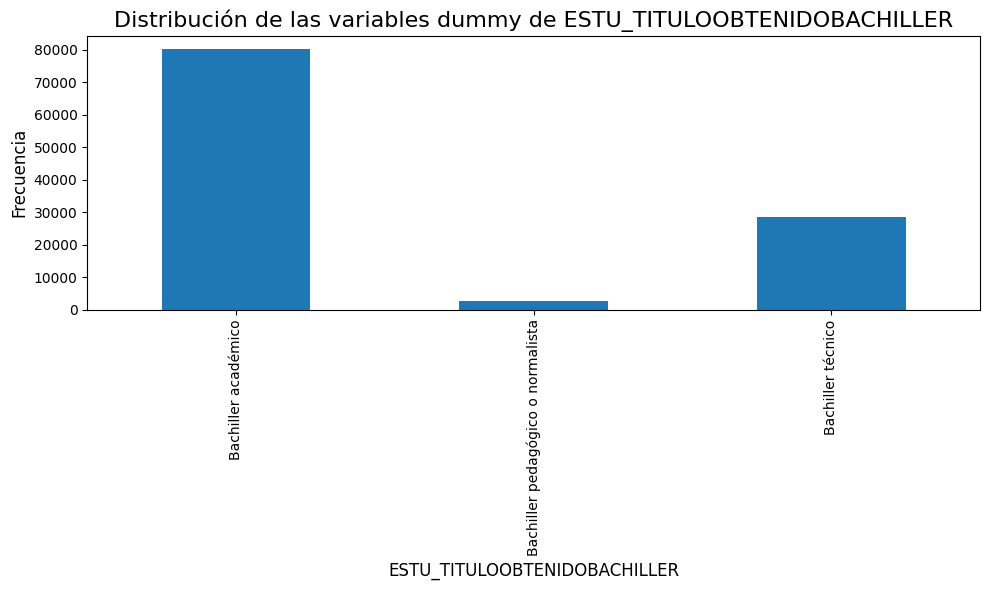

In [21]:
MODAL = df['ESTU_TITULOOBTENIDOBACHILLER'].value_counts().idxmax()
df['ESTU_TITULOOBTENIDOBACHILLER'] = df['ESTU_TITULOOBTENIDOBACHILLER'].fillna(MODAL)

dummies = pd.concat([pd.get_dummies(df['ESTU_TITULOOBTENIDOBACHILLER'], prefix='ESTU_TITULOOBTENIDOBACHILLER', drop_first=True)], axis=1)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['ESTU_TITULOOBTENIDOBACHILLER']), 'ESTU_TITULOOBTENIDOBACHILLER')

MODAL = dfTest['ESTU_TITULOOBTENIDOBACHILLER'].value_counts().idxmax()
dfTest['ESTU_TITULOOBTENIDOBACHILLER'] = dfTest['ESTU_TITULOOBTENIDOBACHILLER'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['ESTU_TITULOOBTENIDOBACHILLER'], prefix='ESTU_TITULOOBTENIDOBACHILLER', drop_first=True)], axis=1)

ESTU_GENERO

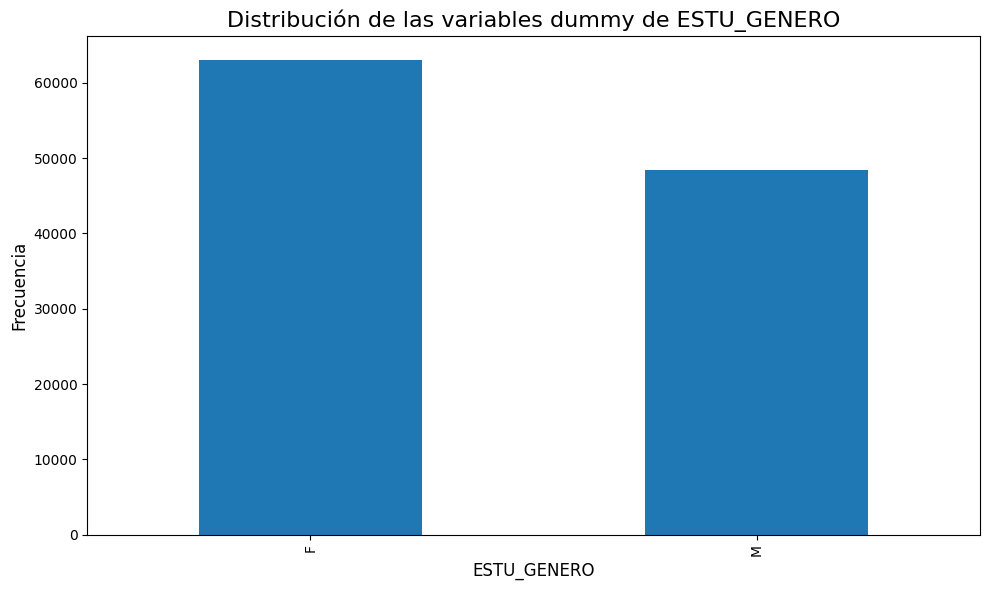

In [23]:
dummies = pd.get_dummies(df['ESTU_GENERO'], prefix='ESTU_GENERO', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['ESTU_GENERO']), 'ESTU_GENERO')

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['ESTU_GENERO'], prefix='ESTU_GENERO', drop_first=True)], axis=1)


ESTU_COMOCAPACITOEXAMENSB11

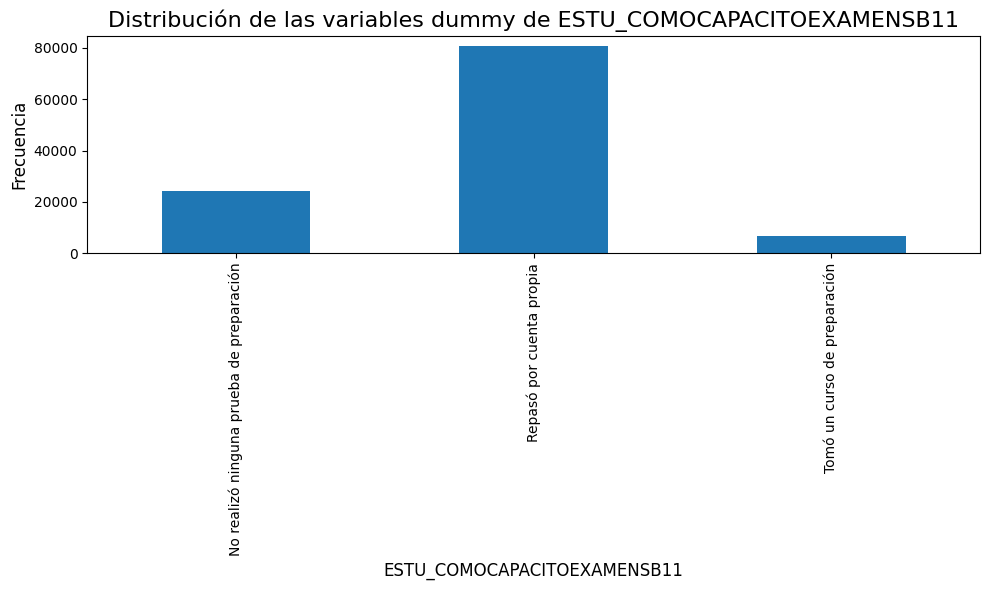

In [24]:
MODAL = df['ESTU_COMOCAPACITOEXAMENSB11'].value_counts().idxmax()
df['ESTU_COMOCAPACITOEXAMENSB11'] = df['ESTU_COMOCAPACITOEXAMENSB11'].fillna(MODAL)

dummies = pd.get_dummies(df['ESTU_COMOCAPACITOEXAMENSB11'], prefix='ESTU_COMOCAPACITOEXAMENSB11', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['ESTU_COMOCAPACITOEXAMENSB11']), 'ESTU_COMOCAPACITOEXAMENSB11')

MODAL = dfTest['ESTU_COMOCAPACITOEXAMENSB11'].value_counts().idxmax()
dfTest['ESTU_COMOCAPACITOEXAMENSB11'] = dfTest['ESTU_COMOCAPACITOEXAMENSB11'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['ESTU_COMOCAPACITOEXAMENSB11'], prefix='ESTU_COMOCAPACITOEXAMENSB11', drop_first=True)], axis=1)


ESTU_TIPODOCUMENTOSB11

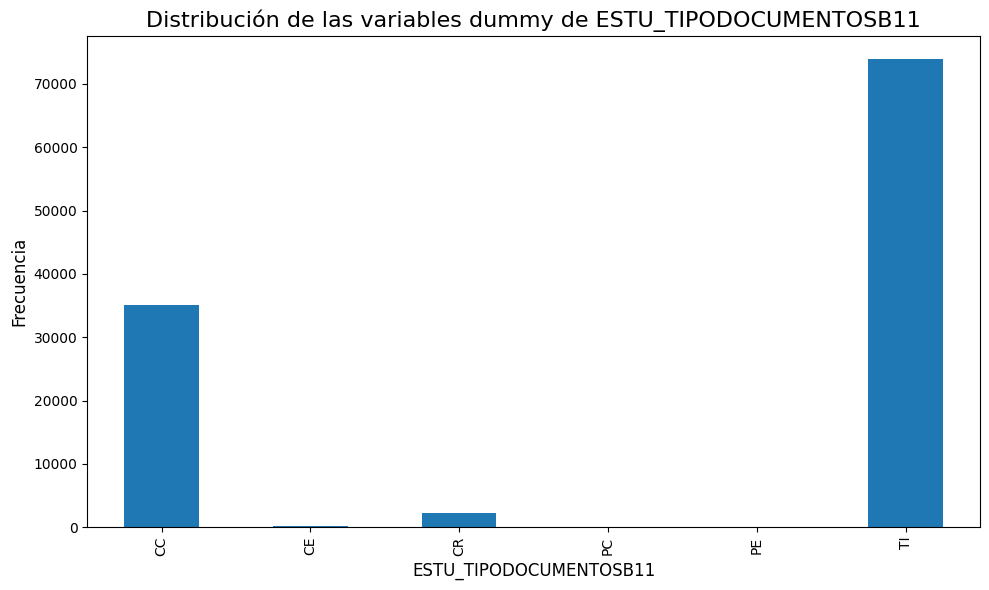

In [25]:
MODAL = df['ESTU_TIPODOCUMENTOSB11'].value_counts().idxmax()
df['ESTU_TIPODOCUMENTOSB11'] = df['ESTU_TIPODOCUMENTOSB11'].fillna(MODAL)

dummies = pd.get_dummies(df['ESTU_TIPODOCUMENTOSB11'], prefix='ESTU_TIPODOCUMENTOSB11', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['ESTU_TIPODOCUMENTOSB11']), 'ESTU_TIPODOCUMENTOSB11')

MODAL = dfTest['ESTU_TIPODOCUMENTOSB11'].value_counts().idxmax()
dfTest['ESTU_TIPODOCUMENTOSB11'] = dfTest['ESTU_TIPODOCUMENTOSB11'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['ESTU_TIPODOCUMENTOSB11'], prefix='ESTU_TIPODOCUMENTOSB11', drop_first=True)], axis=1)

FAMI_EDUCACIONPADRE

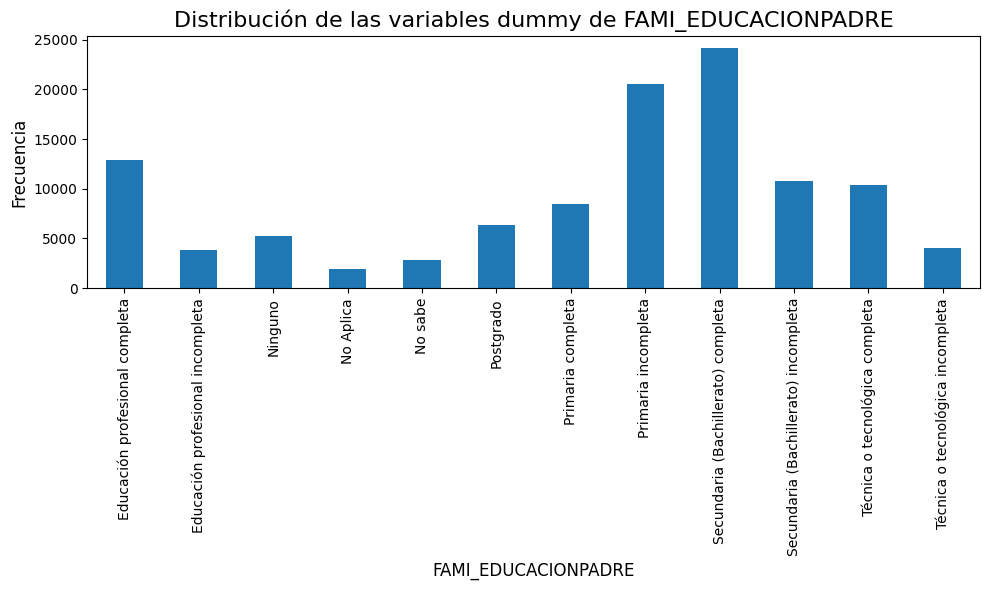

In [26]:
MODAL = df['FAMI_EDUCACIONPADRE'].value_counts().idxmax()
df['FAMI_EDUCACIONPADRE'] = df['FAMI_EDUCACIONPADRE'].fillna(MODAL)

dummies = pd.get_dummies(df['FAMI_EDUCACIONPADRE'], prefix='FAMI_EDUCACIONPADRE', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['FAMI_EDUCACIONPADRE']), 'FAMI_EDUCACIONPADRE')

MODAL = dfTest['FAMI_EDUCACIONPADRE'].value_counts().idxmax()
dfTest['FAMI_EDUCACIONPADRE'] = dfTest['FAMI_EDUCACIONPADRE'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['FAMI_EDUCACIONPADRE'], prefix='FAMI_EDUCACIONPADRE', drop_first=True)], axis=1)

FAMI_EDUCACIONMADRE

In [11]:
MODAL = df['FAMI_EDUCACIONMADRE'].value_counts().idxmax()
df['FAMI_EDUCACIONMADRE'] = df['FAMI_EDUCACIONMADRE'].fillna(MODAL)

dummies = pd.get_dummies(df['FAMI_EDUCACIONMADRE'], prefix='FAMI_EDUCACIONMADRE', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['FAMI_EDUCACIONMADRE']), 'FAMI_EDUCACIONMADRE')

MODAL = dfTest['FAMI_EDUCACIONMADRE'].value_counts().idxmax()
dfTest['FAMI_EDUCACIONMADRE'] = dfTest['FAMI_EDUCACIONMADRE'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['FAMI_EDUCACIONMADRE'], prefix='FAMI_EDUCACIONMADRE', drop_first=True)], axis=1)

FAMI_OCUPACIONPADRE

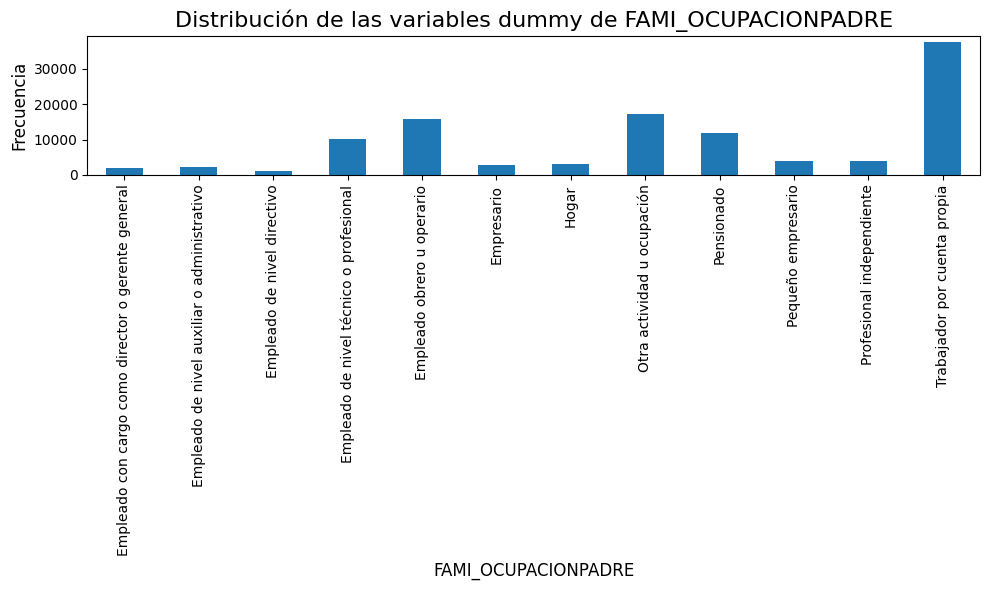

In [27]:
MODAL = df['FAMI_OCUPACIONPADRE'].value_counts().idxmax()
df['FAMI_OCUPACIONPADRE'] = df['FAMI_OCUPACIONPADRE'].fillna(MODAL)

dummies = pd.get_dummies(df['FAMI_OCUPACIONPADRE'], prefix='FAMI_OCUPACIONPADRE', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['FAMI_OCUPACIONPADRE']), 'FAMI_OCUPACIONPADRE')

MODAL = dfTest['FAMI_OCUPACIONPADRE'].value_counts().idxmax()
dfTest['FAMI_OCUPACIONPADRE'] = dfTest['FAMI_OCUPACIONPADRE'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['FAMI_OCUPACIONPADRE'], prefix='FAMI_OCUPACIONPADRE', drop_first=True)], axis=1)

FAMI_OCUPACIONMADRE

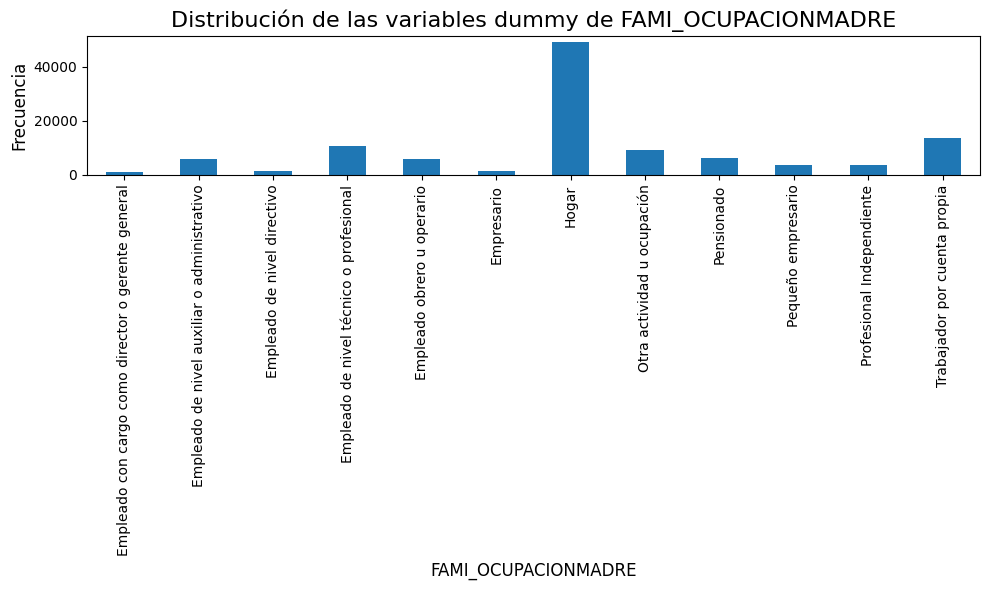

In [28]:
MODAL = df['FAMI_OCUPACIONMADRE'].value_counts().idxmax()
df['FAMI_OCUPACIONMADRE'] = df['FAMI_OCUPACIONMADRE'].fillna(MODAL)

dummies = pd.get_dummies(df['FAMI_OCUPACIONMADRE'], prefix='FAMI_OCUPACIONMADRE', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['FAMI_OCUPACIONMADRE']), 'FAMI_OCUPACIONMADRE')

MODAL = dfTest['FAMI_OCUPACIONMADRE'].value_counts().idxmax()
dfTest['FAMI_OCUPACIONMADRE'] = dfTest['FAMI_OCUPACIONMADRE'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['FAMI_OCUPACIONMADRE'], prefix='FAMI_OCUPACIONMADRE', drop_first=True)], axis=1)

FAMI_TIENECOMPUTADOR

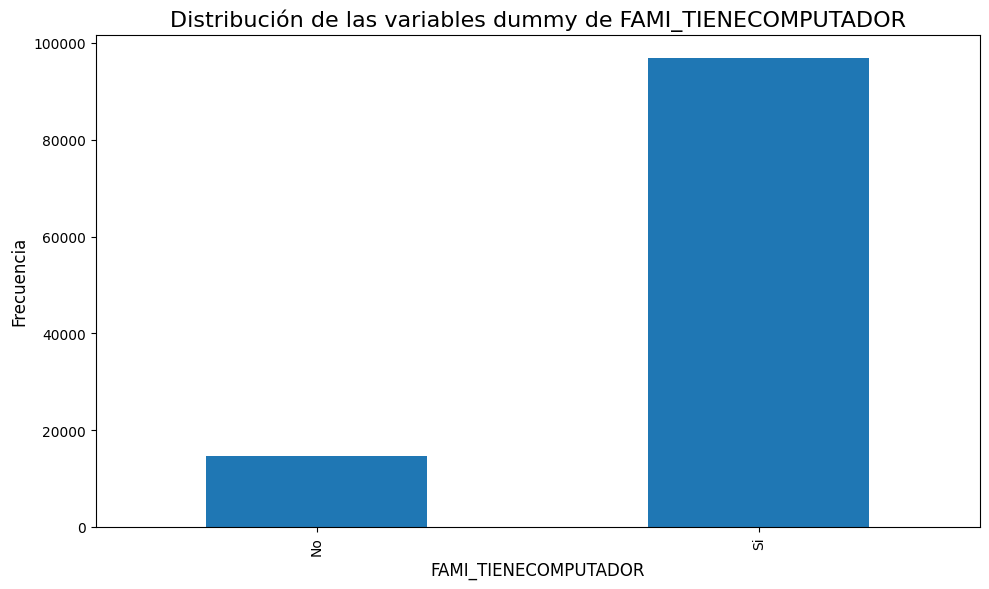

In [29]:
MODAL = df['FAMI_TIENECOMPUTADOR'].value_counts().idxmax()
df['FAMI_TIENECOMPUTADOR'] = df['FAMI_TIENECOMPUTADOR'].fillna(MODAL)

dummies = pd.get_dummies(df['FAMI_TIENECOMPUTADOR'], prefix='FAMI_TIENECOMPUTADOR', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['FAMI_TIENECOMPUTADOR']), 'FAMI_TIENECOMPUTADOR')

MODAL = dfTest['FAMI_TIENECOMPUTADOR'].value_counts().idxmax()
dfTest['FAMI_TIENECOMPUTADOR'] = dfTest['FAMI_TIENECOMPUTADOR'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['FAMI_TIENECOMPUTADOR'], prefix='FAMI_TIENECOMPUTADOR', drop_first=True)], axis=1)

FAMI_TIENECONSOLAVIDEOJUEGOS

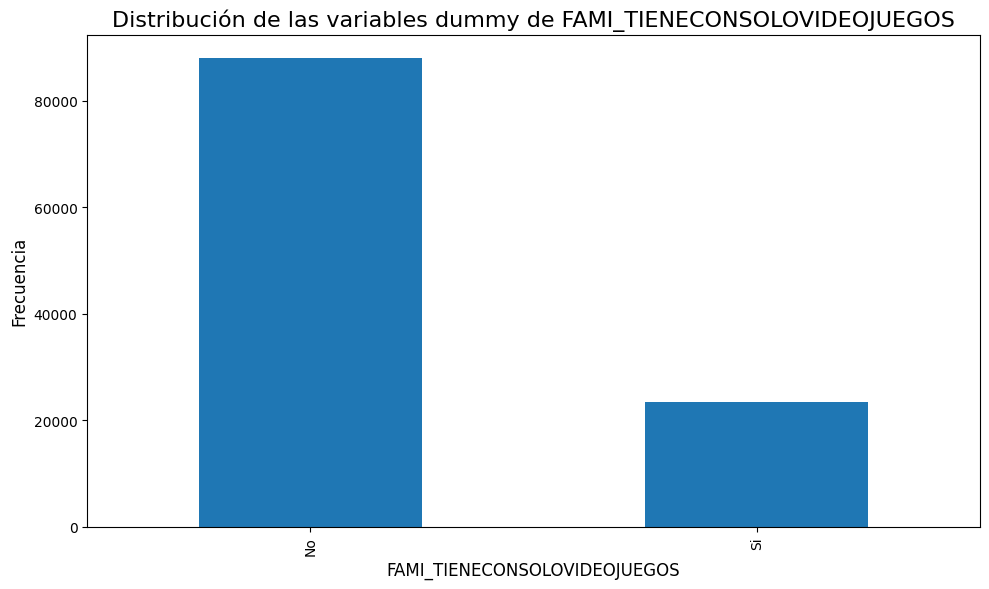

In [30]:
MODAL = df['FAMI_TIENECONSOLAVIDEOJUEGOS'].value_counts().idxmax()
df['FAMI_TIENECONSOLAVIDEOJUEGOS'] = df['FAMI_TIENECONSOLAVIDEOJUEGOS'].fillna(MODAL)

dummies = pd.get_dummies(df['FAMI_TIENECONSOLAVIDEOJUEGOS'], prefix='FAMI_TIENECONSOLAVIDEOJUEGOS', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['FAMI_TIENECONSOLAVIDEOJUEGOS']), 'FAMI_TIENECONSOLOVIDEOJUEGOS')

MODAL = dfTest['FAMI_TIENECONSOLAVIDEOJUEGOS'].value_counts().idxmax()
dfTest['FAMI_TIENECONSOLAVIDEOJUEGOS'] = dfTest['FAMI_TIENECONSOLAVIDEOJUEGOS'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['FAMI_TIENECONSOLAVIDEOJUEGOS'], prefix='FAMI_TIENECONSOLAVIDEOJUEGOS', drop_first=True)], axis=1)

ESTU_HORASSEMANATRABAJA

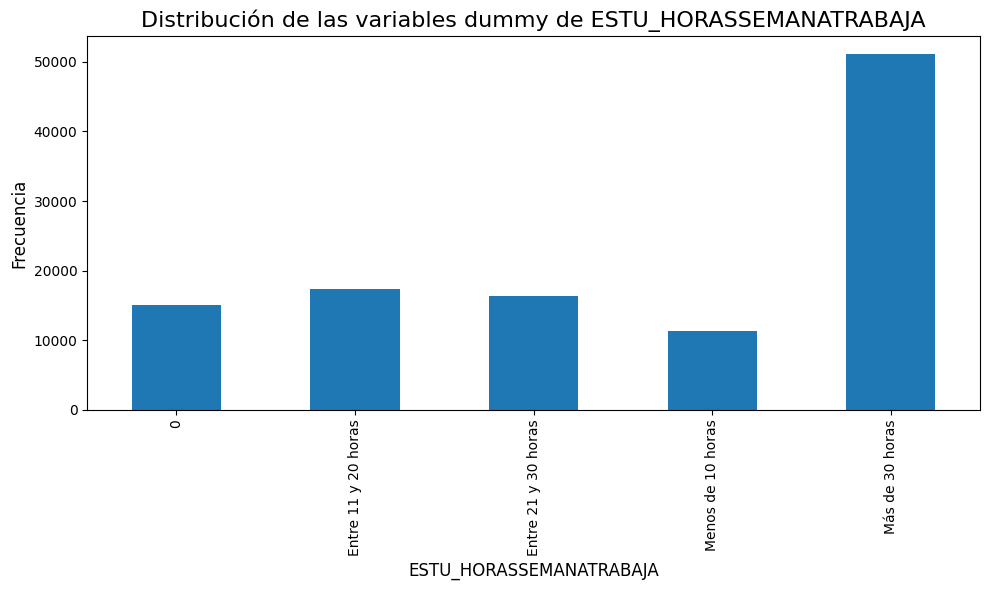

In [31]:
MODAL = df['ESTU_HORASSEMANATRABAJA'].value_counts().idxmax()
df['ESTU_HORASSEMANATRABAJA'] = df['ESTU_HORASSEMANATRABAJA'].fillna(MODAL)

dummies = pd.get_dummies(df['ESTU_HORASSEMANATRABAJA'], prefix='ESTU_HORASSEMANATRABAJA', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['ESTU_HORASSEMANATRABAJA']), 'ESTU_HORASSEMANATRABAJA')

MODAL = dfTest['ESTU_HORASSEMANATRABAJA'].value_counts().idxmax()
dfTest['ESTU_HORASSEMANATRABAJA'] = dfTest['ESTU_HORASSEMANATRABAJA'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['ESTU_HORASSEMANATRABAJA'], prefix='ESTU_HORASSEMANATRABAJA', drop_first=True)], axis=1)

ESTU_VLRULTIMOSEMESCURSADO

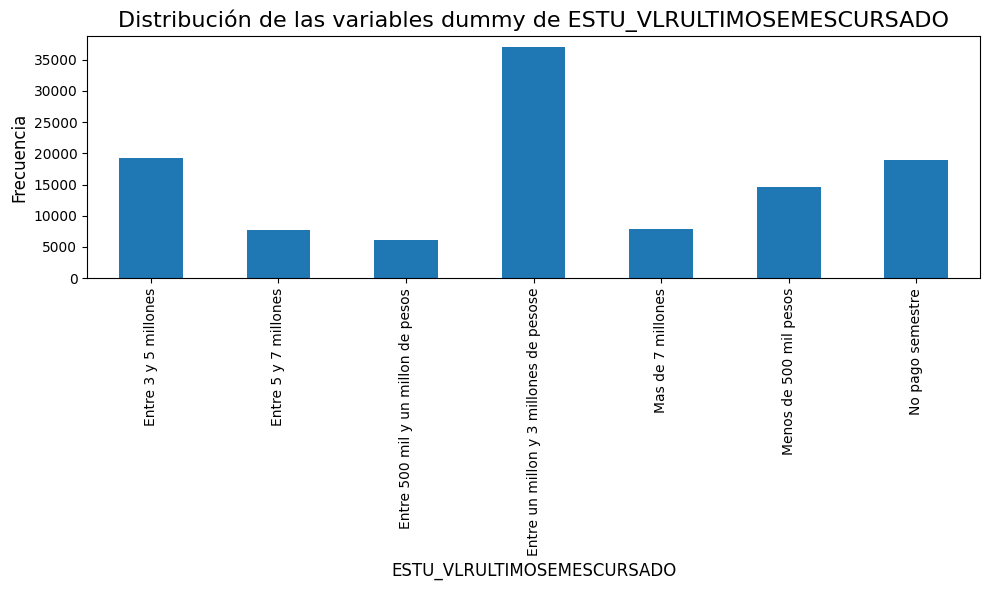

In [32]:
MODAL = df['ESTU_VLRULTIMOSEMESCURSADO'].value_counts().idxmax()
df['ESTU_VLRULTIMOSEMESCURSADO'] = df['ESTU_VLRULTIMOSEMESCURSADO'].fillna(MODAL)

dummies = pd.get_dummies(df['ESTU_VLRULTIMOSEMESCURSADO'], prefix='ESTU_VLRULTIMOSEMESCURSADO', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

generarGraficoDummies(pd.get_dummies(df['ESTU_VLRULTIMOSEMESCURSADO']), 'ESTU_VLRULTIMOSEMESCURSADO')

MODAL = dfTest['ESTU_VLRULTIMOSEMESCURSADO'].value_counts().idxmax()
dfTest['ESTU_VLRULTIMOSEMESCURSADO'] = dfTest['ESTU_VLRULTIMOSEMESCURSADO'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['ESTU_VLRULTIMOSEMESCURSADO'], prefix='ESTU_VLRULTIMOSEMESCURSADO', drop_first=True)], axis=1)

ESTU_PRGM_ACADEMICO

C:\Users\Migue\AppData\Local\Temp\ipykernel_17736\3203882011.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()  # Ajustar los márgenes del gráfico


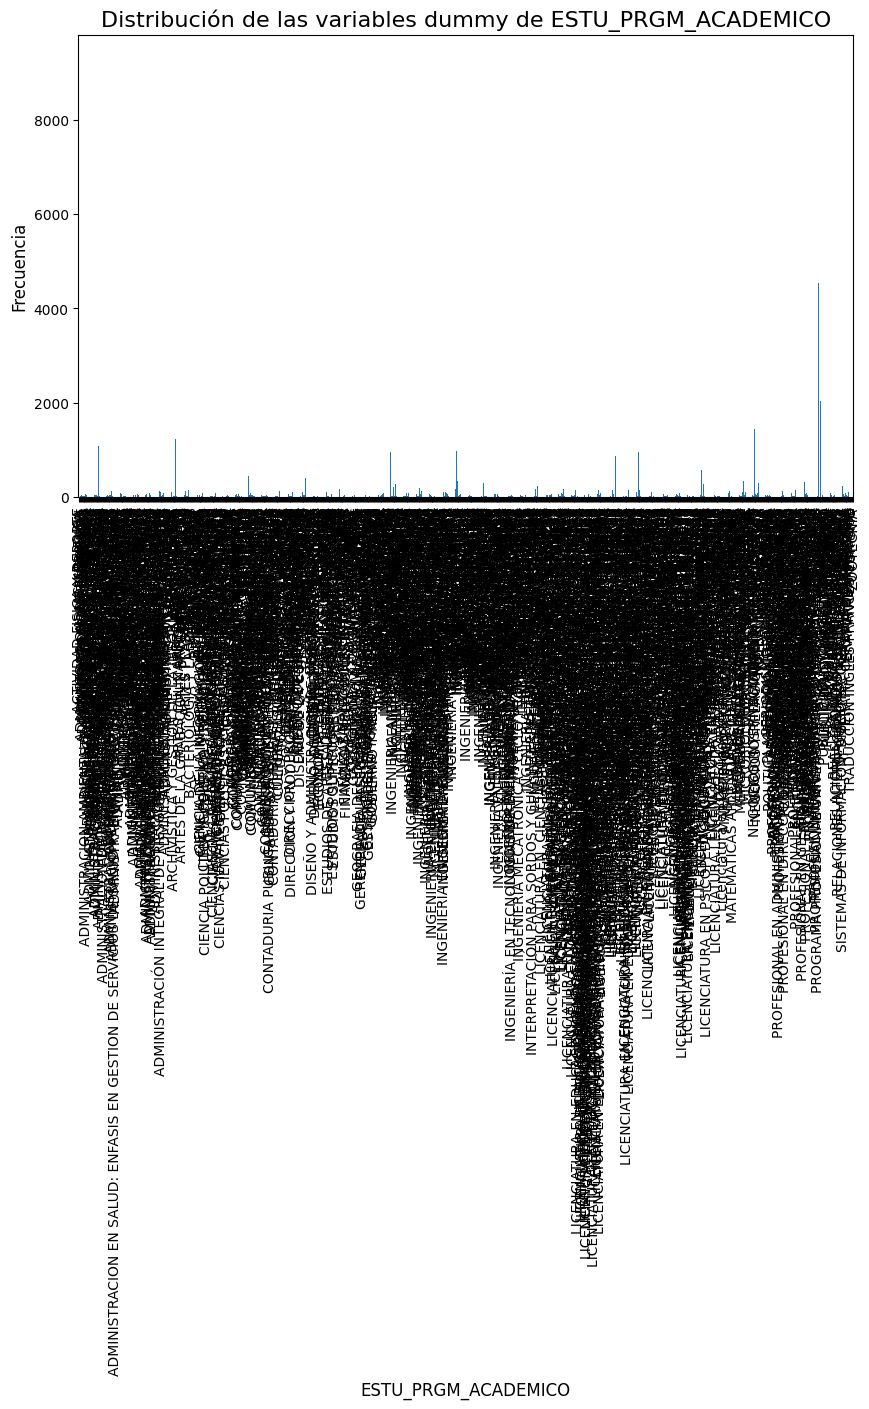

In [33]:
MODAL = df['ESTU_PRGM_ACADEMICO'].value_counts().idxmax()
df['ESTU_PRGM_ACADEMICO'] = df['ESTU_PRGM_ACADEMICO'].fillna(MODAL)

dummies = pd.get_dummies(df['ESTU_PRGM_ACADEMICO'], prefix='ESTU_PRGM_ACADEMICO', drop_first=True)
dfTrain = pd.concat([dfTrain, dummies], axis=1)

#Tiene muchos valores, no se puede generar el gráfico
# generarGraficoDummies(pd.get_dummies(df['ESTU_PRGM_ACADEMICO']), 'ESTU_PRGM_ACADEMICO')

MODAL = dfTest['ESTU_PRGM_ACADEMICO'].value_counts().idxmax()
dfTest['ESTU_PRGM_ACADEMICO'] = dfTest['ESTU_PRGM_ACADEMICO'].fillna(MODAL)

dfTest = pd.concat([dfTest, pd.get_dummies(dfTest['ESTU_PRGM_ACADEMICO'], prefix='ESTU_PRGM_ACADEMICO', drop_first=True)], axis=1)

# Predicción a traves de regresión

In [19]:
# Combinar la columna 'PUNT_GLOBAL' con dfTrain
dfTrain = pd.concat([dfTrain, df[['PUNT_GLOBAL']]], axis=1)

# Eliminar columnas específicas de dfTrain
columnas_a_eliminar = ['ESTU_DEPTO_RESIDE_BERLIN', 'ESTU_DEPTO_RESIDE_CALGARY', 'ESTU_DEPTO_RESIDE_FLANDES ORIENTAL', 'ESTU_DEPTO_RESIDE_GUADALAJARA', 'ESTU_DEPTO_RESIDE_LIMA', 'ESTU_DEPTO_RESIDE_MADRID', 'ESTU_DEPTO_RESIDE_MELBOURNE', 'ESTU_DEPTO_RESIDE_MIAMI', 'ESTU_DEPTO_RESIDE_NUEVA YORK', 'ESTU_DEPTO_RESIDE_PARIS', 'ESTU_DEPTO_RESIDE_VALENCIA', 'ESTU_PRGM_ACADEMICO_ACUICULTURA', 'ESTU_PRGM_ACADEMICO_ADMINISTRACION', 'ESTU_PRGM_ACADEMICO_ADMINISTRACION EN SEGURIDAD Y SALUD EN EL TRABAJO', 'ESTU_PRGM_ACADEMICO_ADMINISTRACION HOTELERA Y DE TURISMO', 'ESTU_PRGM_ACADEMICO_ADMINISTRACION INFORMÁTICA', 'ESTU_PRGM_ACADEMICO_ADMINISTRACION TURÍSTICA', 'ESTU_PRGM_ACADEMICO_ADMINISTRACIÓN DE MERCADEO', 'ESTU_PRGM_ACADEMICO_ADMINISTRACIÓN HOTELERA Y DE SERVICIOS', 'ESTU_PRGM_ACADEMICO_ARTES DE LA ESCENA', 'ESTU_PRGM_ACADEMICO_BANCA Y FINANZAS', 'ESTU_PRGM_ACADEMICO_CIENCIA POLITICA Y RELACIONES INTERNACIONALES', 'ESTU_PRGM_ACADEMICO_CIENCIAS BIBLICAS', 'ESTU_PRGM_ACADEMICO_CIENCIAS CULINARIAS', 'ESTU_PRGM_ACADEMICO_CIENCIAS DE LA COMPUTACIÓN', 'ESTU_PRGM_ACADEMICO_CIENCIAS POLÍTICAS Y RELACIONES INTERNACIONALES', 'ESTU_PRGM_ACADEMICO_CULTURA FÍSICA DEPORTE Y RECREACIÓN', 'ESTU_PRGM_ACADEMICO_DANZA', 'ESTU_PRGM_ACADEMICO_DISEÑO DE MODA', 'ESTU_PRGM_ACADEMICO_DISEÑO VISUAL DIGITAL', 'ESTU_PRGM_ACADEMICO_DISEÑO Y GESTIÓN DEL PRODUCTO', 'ESTU_PRGM_ACADEMICO_ECOLOGÍA', 'ESTU_PRGM_ACADEMICO_ESTUDIOS DE ARTES LIBERALES EN CIENCIAS SOCIALES', 'ESTU_PRGM_ACADEMICO_ESTUDIOS EN FILOSOFIA', 'ESTU_PRGM_ACADEMICO_ESTUDIOS SUPERIORES EN INSTRUMENTO O CANTO', 'ESTU_PRGM_ACADEMICO_ESTUDIOS Y GESTION CULTURAL', 'ESTU_PRGM_ACADEMICO_FOTOGRAFÍA', 'ESTU_PRGM_ACADEMICO_FÍSICA', 'ESTU_PRGM_ACADEMICO_GASTRONOMÍA', 'ESTU_PRGM_ACADEMICO_GASTRONOMÍA Y ARTES CULINARIAS', 'ESTU_PRGM_ACADEMICO_GESTION EN ECOLOGIA Y TURISMO', 'ESTU_PRGM_ACADEMICO_HISTORIA DEL ARTE', 'ESTU_PRGM_ACADEMICO_INGENIERIA DE DISEÑO DE PRODUCTO', 'ESTU_PRGM_ACADEMICO_INGENIERIA DE PLASTICOS', 'ESTU_PRGM_ACADEMICO_INGENIERIA DE SOFTWARE Y COMPUTACIÓN', 'ESTU_PRGM_ACADEMICO_INGENIERIA EN CONTROL ELECTRONICO E INSTRUMENTACION', 'ESTU_PRGM_ACADEMICO_INGENIERIA PECUARIA', 'ESTU_PRGM_ACADEMICO_INGENIERÍA AEROESPACIAL', 'ESTU_PRGM_ACADEMICO_INGENIERÍA AERONÁUTICA', 'ESTU_PRGM_ACADEMICO_INGENIERÍA BIOQUÍMICA', 'ESTU_PRGM_ACADEMICO_INGENIERÍA DE PETRÓLEOS', 'ESTU_PRGM_ACADEMICO_INGENIERÍA EN AUTOMATIZACIÓN', 'ESTU_PRGM_ACADEMICO_INGENIERÍA EN ENERGÍAS RENOVABLES', 'ESTU_PRGM_ACADEMICO_INGENIERÍA EN TELECOMUNICACIONES', 'ESTU_PRGM_ACADEMICO_INGENIERÍA ENERGÉTICA', 'ESTU_PRGM_ACADEMICO_INGENIERÍA GEOLÓGICA', 'ESTU_PRGM_ACADEMICO_INGENIERÍA OCEANOGRÁFICA', 'ESTU_PRGM_ACADEMICO_INVESTIGACION CRIMINAL', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN  FILOSOFIA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN  MATEMATICAS Y FISICA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN BIOLOGIA CON ENFASIS EN EDUCACION AMBIENTAL', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN CULTURA FISICA, RECREACION, EDUCACION FISICA Y DEPORTE', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN EDUCACION ARTISTICA Y ARTES ESCENICAS', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN EDUCACION BASICA CON ENFASIS EN HUMANIDADES, ESPAÑOL Y LENGUAS EXTRANJERAS', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN EDUCACION CON ENFASIS EN EDUCACION ESPECIAL', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN EDUCACION ENFASIS EN MATEMATICAS', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN EDUCACION FISICA,RECREACION Y DEPORTES', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN EDUCACION RELIGIOSA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN EDUCACIÓN FÍSICA Y DEPORTES', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN ESPAÑOL Y COMUNICACION EDUCATIVA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN FILOSOFIA E HISTORIA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN FILOSOFIA Y HUMANIDADES', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN FILOSOFIA Y LENGUA CASTELLANA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN FILOSOFÍA Y HUMANIDADES', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN FÍSICA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN IDIOMAS MODERNOS ESPAÑOL- INGLES', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN LENGUAS EXTRANJERAS CON ÉNFASIS EN INGLÉS Y FRANCÉS', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN LENGUAS EXTRANJERAS INGLES-FRANCES', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN LITERATURA Y LENGUA ESPAÑOLA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN PRODUCCION AGROPECUARIA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN PSICOLOGIA Y PEDAGOGIA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN TEATRO', 'ESTU_PRGM_ACADEMICO_LICENCIATURA EN TECNOLOGIA E INFORMATICA', 'ESTU_PRGM_ACADEMICO_LICENCIATURA LENGUAS EXTRANJERAS CON ENFASIS EN INGLES', 'ESTU_PRGM_ACADEMICO_LOGISTICA EMPRESARIAL', 'ESTU_PRGM_ACADEMICO_MAESTRO EN MÚSICA', 'ESTU_PRGM_ACADEMICO_MARKETING', 'ESTU_PRGM_ACADEMICO_MARKETING INTEGRAL Y NEGOCIOS GLOBALES', 'ESTU_PRGM_ACADEMICO_MARKETING Y NEGOCIOS DIGITALES', 'ESTU_PRGM_ACADEMICO_MATEMATICAS APLICADAS', 'ESTU_PRGM_ACADEMICO_MERCADEO DIGITAL', 'ESTU_PRGM_ACADEMICO_MICROBIOLOGIA INDUSTRIAL Y AMBIENTAL', 'ESTU_PRGM_ACADEMICO_OCEANOGRAFÍA', 'ESTU_PRGM_ACADEMICO_PRODUCCION AGROINDUSTRIAL', 'ESTU_PRGM_ACADEMICO_PROFESIONAL  EN DISEÑO GRAFICO', 'ESTU_PRGM_ACADEMICO_PROFESIONAL EN ADMINISTRACION DE EMPRESAS', 'ESTU_PRGM_ACADEMICO_PROFESIONAL EN BANCA Y FINANZAS', 'ESTU_PRGM_ACADEMICO_PROFESIONAL EN CINE Y TELEVISION', 'ESTU_PRGM_ACADEMICO_PROFESIONAL EN GASTRONOMíA', 'ESTU_PRGM_ACADEMICO_PROFESIONAL EN MERCADEO EMPRESARIAL', 'ESTU_PRGM_ACADEMICO_PSICOLOGÍA.', 'ESTU_PRGM_ACADEMICO_PUBLICIDAD Y MARKETING CREATIVO', 'ESTU_PRGM_ACADEMICO_PUBLICIDAD Y MARKETING DIGITAL', 'ESTU_PRGM_ACADEMICO_REALIZACIÓN Y PRODUCCIÓN MUSICAL']
dfTrain.drop(columns=columnas_a_eliminar, inplace=True)

# Definir las variables predictoras y objetivo
predictores = dfTrain.drop('PUNT_GLOBAL', axis=1)
objetivo = dfTrain['PUNT_GLOBAL']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(predictores, objetivo, test_size=0.30, random_state=42)

# Crear y entrenar el modelo de regresión
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
predicciones = modelo_lineal.predict(X_test)

# Calcular las métricas de rendimiento
r2 = r2_score(y_test, predicciones)
mape = mean_absolute_percentage_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)

# Imprimir los resultados de las métricas
print(f"Coeficiente de determinación R²: {r2}")
print(f"Error porcentual absoluto medio (MAPE): {mape}")
print(f"Error cuadrático medio (MSE): {mse}")

# Predecir en el conjunto dfTest
predicciones_finales = modelo_lineal.predict(dfTest[predictores.columns])

# Generar el archivo CSV con los resultados
resultado_final = pd.DataFrame({
    'id': dfTest['ESTU_CONSECUTIVO'],
    'GLOBAL_SCORE': predicciones_finales
})

# Exportar el archivo CSV
resultado_final.to_csv('resultado_regresion.csv', index=False)
print("Archivo 'resultado_regresion.csv' generado con éxito.")

Coeficiente de determinación R²: 0.3120445634423703
Error porcentual absoluto medio (MAPE): 19783856825415.684
Error cuadrático medio (MSE): 379.21760366002314
Archivo 'resultado_regresion.csv' generado con éxito.


## Predicción a traves de KNN

In [20]:
# Definir las variables predictoras y la variable objetivo
predictoras = dfTrain.drop(columns=['PUNT_GLOBAL'])
objetivo = dfTrain['PUNT_GLOBAL']

# Dividir los datos en entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(predictoras, objetivo, test_size=0.30, random_state=42)

# Escalador para las características
escalador = StandardScaler()

# Escalar los datos de entrenamiento y prueba
X_train_normalizado = escalador.fit_transform(X_train)
X_test_normalizado = escalador.transform(X_test)

# Lista de números de vecinos a probar
opciones_vecinos = [5, 10, 20, 30]
mse_resultados = {}

# Probar KNN con diferentes valores de vecinos
for num_vecinos in opciones_vecinos:
    modelo_knn = KNeighborsRegressor(n_neighbors=num_vecinos)
    modelo_knn.fit(X_train_normalizado, y_train)
    
    # Hacer predicciones y calcular MSE
    predicciones_knn = modelo_knn.predict(X_test_normalizado)
    error_cuadratico_medio = mean_squared_error(y_test, predicciones_knn)
    
    # Guardar el MSE en el diccionario de resultados
    mse_resultados[num_vecinos] = error_cuadratico_medio
    print(f"MSE con {num_vecinos} vecinos: {error_cuadratico_medio}")

# Seleccionar el número de vecinos que minimiza el MSE
mejor_num_vecinos = min(mse_resultados, key=mse_resultados.get)
print(f"El mejor número de vecinos es {mejor_num_vecinos} con un MSE de {mse_resultados[mejor_num_vecinos]}")

# Usar el mejor número de vecinos para predecir en dfTest
mejor_num_vecinos = 30  # Cambia a lo que obtuviste como el mejor valor en tus pruebas anteriores

# Escalar los datos de prueba (dfTest)
caracteristicas_test = dfTest[list(predictoras.columns)]
caracteristicas_test_normalizado = escalador.transform(caracteristicas_test)

# Crear y entrenar el modelo con el mejor número de vecinos
modelo_knn_final = KNeighborsRegressor(n_neighbors=mejor_num_vecinos)
modelo_knn_final.fit(X_train_normalizado, y_train)

# Hacer predicciones en los datos reales de prueba
predicciones_finales = modelo_knn_final.predict(caracteristicas_test_normalizado)

# Crear un DataFrame para guardar los resultados
resultado_final = pd.DataFrame({
    'id': dfTest['ESTU_CONSECUTIVO'],
    'GLOBAL_SCORE': predicciones_finales
})

# Exportar los resultados a un archivo CSV
resultado_final.to_csv('resultado_knn.csv', index=False)
print("Archivo 'resultado_knn.csv' generado exitosamente.")

MSE con 5 vecinos: 453.95408178527623
MSE con 10 vecinos: 419.4937640970415
MSE con 20 vecinos: 407.5644615453648
MSE con 30 vecinos: 405.9491958412689
El mejor número de vecinos es 30 con un MSE de 405.9491958412689
Archivo 'resultado_knn.csv' generado exitosamente.


## Predicción a traves de GBM

In [21]:
# Separar características y variable objetivo
variables_pred = dfTrain.drop(columns=['PUNT_GLOBAL'])
objetivo = dfTrain['PUNT_GLOBAL']

# Dividir el dataset en conjunto de entrenamiento y prueba (70%-30%)
entrenamiento_x, prueba_x, entrenamiento_y, prueba_y = train_test_split(variables_pred, objetivo, test_size=0.30, random_state=42)

# Aplicar escalado a los datos
normalizador = StandardScaler()
entrenamiento_x_norm = normalizador.fit_transform(entrenamiento_x)
prueba_x_norm = normalizador.transform(prueba_x)

# Definir y entrenar el modelo GBM (Gradient Boosting Machine)
modelo_gbm = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
modelo_gbm.fit(entrenamiento_x_norm, entrenamiento_y)

# Realizar predicciones en el conjunto de entrenamiento y prueba
prediccion_entrenamiento = modelo_gbm.predict(entrenamiento_x_norm)
prediccion_prueba = modelo_gbm.predict(prueba_x_norm)

# Calcular métricas (MSE y MAPE) para los datos de entrenamiento
error_medio_entrenamiento = mean_squared_error(entrenamiento_y, prediccion_entrenamiento)
mape_entrenamiento = mean_absolute_percentage_error(entrenamiento_y, prediccion_entrenamiento)

# Calcular métricas (MSE y MAPE) para los datos de prueba
error_medio_prueba = mean_squared_error(prueba_y, prediccion_prueba)
mape_prueba = mean_absolute_percentage_error(prueba_y, prediccion_prueba)

# Imprimir las métricas de evaluación
print(f"Error cuadrático medio en entrenamiento (MSE): {error_medio_entrenamiento}")
print(f"Error porcentual absoluto medio en entrenamiento (MAPE): {mape_entrenamiento}")
print(f"Error cuadrático medio en prueba (MSE): {error_medio_prueba}")
print(f"Error porcentual absoluto medio en prueba (MAPE): {mape_prueba}")

# Predecir en los datos de prueba reales (dfTest)
datos_test_reales = dfTest[list(variables_pred.columns)]
datos_test_norm = normalizador.transform(datos_test_reales)

prediccion_final = modelo_gbm.predict(datos_test_norm)

# Crear un DataFrame para los resultados
resultados_finales = pd.DataFrame({
    'id': dfTest['ESTU_CONSECUTIVO'],
    'GLOBAL_SCORE': prediccion_final
})

# Guardar los resultados en un archivo CSV
resultados_finales.to_csv('prediccion_gbm.csv', index=False)
print("Archivo 'prediccion_gbm.csv' generado exitosamente.")

Error cuadrático medio en entrenamiento (MSE): 408.01594915444775
Error porcentual absoluto medio en entrenamiento (MAPE): 8147006302617.829
Error cuadrático medio en prueba (MSE): 412.2192074862684
Error porcentual absoluto medio en prueba (MAPE): 19122932537627.492
Archivo 'prediccion_gbm.csv' generado exitosamente.
